# Financial Returns Prediction with LSTM (MLX)

This notebook mirrors the XGBoost workflow (`513_financial_xgboost.ipynb`) but trains sequence models using **MLX** (Apple Silicon). It keeps the same data prep and feature definitions so you can compare models side-by-side.

> Requires the MLX package (Apple Silicon). Install if needed: `pip install mlx` (and optionally `pip install mlx-lm`).

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlx.core as mx
import mlx.nn as nn
from mlx.optimizers import AdamW

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Display and plotting options
pd.options.display.float_format = "{:.4f}".format
plt.rcParams["figure.figsize"] = (12, 4)

DATA_DIR = "./data/"
OUTPUT_DIR = "./data/"

RAW_FINANCIAL_FILE = DATA_DIR + "market_data.json"
EPI_FILE = DATA_DIR + "epi_data.json"

# Analysis window (same as XGBoost notebook)
START_DATE = "2025-01-01"
END_DATE = "2025-05-31"

np.random.seed(42)
mx.random.seed(42)


## 1. Load and Prepare Data

In [2]:

# --- Load raw financial data ---
try:
    df_raw = pd.read_json(RAW_FINANCIAL_FILE)
except ValueError:
    df_raw = pd.read_csv(RAW_FINANCIAL_FILE)

if "Date_" not in df_raw.columns:
    raise KeyError("Expected a 'Date_' column in the market data file.")

# Parse dates and sort
df_raw["Date_"] = pd.to_datetime(df_raw["Date_"])
df_raw = df_raw.sort_values("Date_").set_index("Date_")

# Rename columns to simpler names (matches XGBoost notebook)
rename_map = {
    "Close_BTC-USD": "close_btc",
    "Close_GC=F": "close_gold",
    "Close_CL=F": "close_oil",
    "Close_^GSPC": "close_spx",
    "Close_CNY=X": "close_usdcny",
    "Close_EUR=X": "close_eurusd",
    "Close_^TNX": "close_ust10y",
    "Volume_BTC-USD": "vol_btc",
    "Volume_GC=F": "vol_gold",
    "Volume_^GSPC": "vol_spx",
}

df = df_raw.rename(columns=rename_map)

# Create business-day index and forward-fill prices
full_index = pd.date_range(df.index.min(), df.index.max(), freq="B")
df = df.reindex(full_index)
price_cols = [c for c in df.columns if c.startswith("close_")]
df[price_cols] = df[price_cols].ffill()

# Construct returns and control variables
def log_return(series):
    return np.log(series).diff()

returns = pd.DataFrame(index=df.index)
returns["r_btc"] = log_return(df["close_btc"])
returns["r_gold"] = log_return(df["close_gold"])
returns["r_spx"] = log_return(df["close_spx"])

returns["dln_eurusd"] = log_return(df["close_eurusd"])
returns["dln_usdcny"] = log_return(df["close_usdcny"])
returns["dln_oil"] = log_return(df["close_oil"])
returns["dy10"] = df["close_ust10y"].diff()

returns = returns.dropna().loc[START_DATE:END_DATE]

# Load EPI data
df_epi = pd.read_json(EPI_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

epi_cols = [col for col in df_epi.columns if col.startswith('epi') or col in ['ei_creator', 'ei_community']]

returns = returns.join(df_epi[epi_cols], how='left')
returns[epi_cols] = returns[epi_cols].fillna(0)

print(f"Data window: {returns.index.min().date()} to {returns.index.max().date()}")
print(f"Columns: {returns.columns.tolist()}")


Data window: 2025-01-01 to 2025-05-30
Columns: ['r_btc', 'r_gold', 'r_spx', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'ei_creator', 'ei_community', 'epi', 'epi_weighted', 'epi_', 'epi_Environmental and Infrastructure', 'epi_Labor and Workforce', 'epi_Health and Social Welfare', 'epi_Legal and Regulatory Framework', 'epi_Education and Knowledge', 'epi_Psychological and Emotional Aspects', 'epi_Leadership and Governance', 'epi_Economic and Financial Matters', 'epi_Disaster and Resilience', 'epi_Security and Conflict', 'epi_Disputes and Opinions', 'epi_Miscellaneous and Other', 'epi_Sports and Recreation', 'epi_Power and Influence Dynamics', 'epi_Social and Cultural Aspects', 'epi_Quality of Life and Standards', 'epi_Trust, Credibility, and Communication', 'epi_Conspiracy and Historical Events']


## 2. Feature Engineering (lags, asymmetry, rolling stats)

In [3]:

max_lag = 5
data = returns.copy()

for asset in ["r_btc", "r_gold", "r_spx"]:
    for lag in range(1, max_lag + 1):
        data[f"{asset}_l{lag}"] = data[asset].shift(lag)

for lag in range(1, max_lag + 1):
    data[f'epi_l{lag}'] = data['epi'].shift(lag)
    data[f'epi_weighted_l{lag}'] = data['epi_weighted'].shift(lag)

# Asymmetric and rolling stats
data['epi_pos'] = np.maximum(data['epi'], 0)
data['epi_neg'] = np.minimum(data['epi'], 0)
data['epi_weighted_pos'] = np.maximum(data['epi_weighted'], 0)
data['epi_weighted_neg'] = np.minimum(data['epi_weighted'], 0)

data['epi_ma5'] = data['epi'].rolling(5).mean()
data['epi_std5'] = data['epi'].rolling(5).std()
data['epi_weighted_ma5'] = data['epi_weighted'].rolling(5).mean()
data['epi_weighted_std5'] = data['epi_weighted'].rolling(5).std()

for asset in ["r_btc", "r_gold", "r_spx"]:
    data[f"{asset}_vol5"] = data[asset].rolling(5).std()

data = data.dropna()
print(f"Feature-engineered data shape: {data.shape}")


Feature-engineered data shape: (103, 66)


## 3. Feature Sets (same definitions as XGBoost notebook)

In [4]:

control_cols = ["dln_eurusd", "dln_usdcny", "dln_oil", "dy10"]


def get_feature_cols(asset, model_type="baseline"):
    """
    Return feature columns for each model type.
    - baseline: lagged returns + controls + vol
    - epi / epi_weighted: add contemporaneous EPI variant
    - epi_lagged: add EPI lags
    - epi_full: asymmetric + lags + rolling stats
    - epi_weighted_full: weighted version of epi_full
    """
    lag_cols = [f"{asset}_l{lag}" for lag in range(1, 4)]
    other_assets = [a for a in ["r_btc", "r_gold", "r_spx"] if a != asset]
    cross_cols = [f"{a}_l1" for a in other_assets]
    vol_cols = [f"{asset}_vol5"]
    base_features = lag_cols + cross_cols + control_cols + vol_cols

    if model_type == "baseline":
        return base_features
    if model_type == "epi":
        return base_features + ["epi"]
    if model_type == "epi_weighted":
        return base_features + ["epi_weighted"]
    if model_type == "epi_lagged":
        epi_lags = [f"epi_l{lag}" for lag in range(1, 4)]
        return base_features + epi_lags
    if model_type == "epi_asymmetric":
        return base_features + ["epi_pos", "epi_neg"]
    if model_type == "epi_full":
        epi_lags = [f"epi_l{lag}" for lag in range(1, 4)]
        epi_roll = ["epi_ma5", "epi_std5"]
        return base_features + ["epi", "epi_pos", "epi_neg"] + epi_lags + epi_roll
    if model_type == "epi_weighted_full":
        epi_lags = [f"epi_weighted_l{lag}" for lag in range(1, 4)]
        epi_roll = ["epi_weighted_ma5", "epi_weighted_std5"]
        return base_features + ["epi_weighted", "epi_weighted_pos", "epi_weighted_neg"] + epi_lags + epi_roll
    raise ValueError(f"Unknown model type: {model_type}")

print(get_feature_cols("r_btc", "epi_full"))


['r_btc_l1', 'r_btc_l2', 'r_btc_l3', 'r_gold_l1', 'r_spx_l1', 'dln_eurusd', 'dln_usdcny', 'dln_oil', 'dy10', 'r_btc_vol5', 'epi', 'epi_pos', 'epi_neg', 'epi_l1', 'epi_l2', 'epi_l3', 'epi_ma5', 'epi_std5']


## 4. MLX LSTM helpers (sequence builder, model, training loop)

In [12]:
from typing import Dict, List, Tuple
import copy
import mlx.utils


def make_sequences(features: np.ndarray, targets: np.ndarray, seq_len: int, index: pd.Index):
    X_seq, y_seq, seq_dates = [], [], []
    for i in range(seq_len, len(features)):
        X_seq.append(features[i - seq_len : i])
        y_seq.append(targets[i])
        seq_dates.append(index[i])
    return (
        np.array(X_seq, dtype=np.float32),
        np.array(y_seq, dtype=np.float32),
        pd.Index(seq_dates),
    )


def compute_metrics(actuals: np.ndarray, preds: np.ndarray) -> Dict[str, float]:
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    dir_acc = np.mean(np.sign(actuals) == np.sign(preds)) * 100
    return {"rmse": rmse, "mae": mae, "dir_acc": dir_acc}


def copy_weights(weights):
    """Deep copy model weights (nested dict of arrays)."""
    return mlx.utils.tree_map(lambda x: mx.array(x), weights)


class LSTMRegressor(nn.Module):
    """Stacked LSTM for univariate regression using MLX.
    
    MLX's nn.LSTM doesn't support num_layers or dropout directly,
    so we manually stack LSTM layers and apply dropout between them.
    """

    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout_rate = dropout
        
        # Stack LSTM layers manually
        self.lstm_layers = []
        for i in range(num_layers):
            layer_input_size = input_size if i == 0 else hidden_size
            self.lstm_layers.append(nn.LSTM(layer_input_size, hidden_size))
        
        # Dropout layers between LSTM layers
        self.dropout = nn.Dropout(p=dropout) if dropout > 0 else None
        
        # Output head
        self.head = nn.Linear(hidden_size, 1)

    def __call__(self, x):
        # x shape: (batch, seq_len, features)
        # MLX LSTM expects (seq_len, batch, features)
        out = mx.swapaxes(x, 0, 1)
        
        for i, lstm in enumerate(self.lstm_layers):
            out, _ = lstm(out)
            # Apply dropout between layers (not after the last layer)
            if self.dropout is not None and i < self.num_layers - 1:
                out = self.dropout(out)
        
        # Swap back: (seq_len, batch, hidden) -> (batch, seq_len, hidden)
        out = mx.swapaxes(out, 0, 1)
        
        # Take the last timestep
        last = out[:, -1, :]
        return self.head(last).squeeze(-1)


def train_lstm_model(
    df: pd.DataFrame,
    asset: str,
    feature_cols: List[str],
    seq_len: int = 25,
    hidden_size: int = 64,
    num_layers: int = 2,
    dropout: float = 0.1,
    learning_rate: float = 3e-3,
    epochs: int = 80,
    batch_size: int = 32,
    patience: int = 8,
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
):
    df_fit = df.dropna(subset=[asset] + feature_cols)
    if len(df_fit) <= seq_len + 5:
        return {"error": "Insufficient data after lagging for LSTM."}

    # Time-based split indices on the original rows
    train_end = int(len(df_fit) * train_ratio)
    val_end = int(len(df_fit) * (train_ratio + val_ratio))

    features = df_fit[feature_cols].values.astype(np.float32)
    target = df_fit[asset].values.astype(np.float32)

    scaler = StandardScaler()
    scaler.fit(features[:train_end])  # fit on train to avoid leakage
    features_scaled = scaler.transform(features)

    X_seq, y_seq, seq_dates = make_sequences(features_scaled, target, seq_len, df_fit.index)

    train_cut = max(train_end - seq_len, 1)
    val_cut = max(val_end - seq_len, train_cut + 1)

    X_train, y_train = X_seq[:train_cut], y_seq[:train_cut]
    X_val, y_val = X_seq[train_cut:val_cut], y_seq[train_cut:val_cut]
    X_test, y_test = X_seq[val_cut:], y_seq[val_cut:]
    date_test = seq_dates[val_cut:]

    if len(X_test) == 0:
        return {"error": "Test window empty; reduce seq_len or adjust split."}

    model = LSTMRegressor(X_train.shape[-1], hidden_size=hidden_size, num_layers=num_layers, dropout=dropout)
    optimizer = AdamW(learning_rate=learning_rate, weight_decay=1e-4)

    def loss_fn(model, xb, yb):
        preds = model(xb)
        return mx.mean((preds - yb) ** 2)

    loss_and_grad = nn.value_and_grad(model, loss_fn)

    best_weights = None
    best_val = np.inf
    wait = 0

    for epoch in range(epochs):
        perm = np.random.permutation(len(X_train))
        for start in range(0, len(perm), batch_size):
            idx = perm[start : start + batch_size]
            xb = mx.array(X_train[idx])
            yb = mx.array(y_train[idx])
            loss, grads = loss_and_grad(model, xb, yb)
            optimizer.update(model, grads)
            mx.eval(model.parameters(), optimizer.state)

        if len(X_val):
            val_pred = model(mx.array(X_val))
            val_loss = float(mx.mean((val_pred - mx.array(y_val)) ** 2))
        else:
            val_loss = float(loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d} | Train loss {float(loss):.6f} | Val loss {val_loss:.6f}")

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            # Use parameters() which returns just the trainable arrays
            best_weights = copy_weights(model.parameters())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_weights is not None:
        model.update(best_weights)

    test_pred = model(mx.array(X_test))
    test_pred_np = np.asarray(test_pred).reshape(-1)
    metrics = compute_metrics(y_test, test_pred_np)

    preds_series = pd.Series(test_pred_np, index=date_test)
    actual_series = pd.Series(y_test, index=date_test)

    return {
        **metrics,
        "predictions": preds_series,
        "actuals": actual_series,
        "val_loss": best_val,
        "feature_cols": feature_cols,
        "seq_len": seq_len,
        "scaler": scaler,
    }

## 5. Train LSTM models across feature sets

In [13]:

assets = ["r_btc", "r_gold", "r_spx"]
model_types = ["baseline", "epi", "epi_weighted", "epi_full", "epi_weighted_full"]

train_cfg = {
    "seq_len": 25,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.1,
    "learning_rate": 3e-3,
    "epochs": 80,
    "batch_size": 32,
    "patience": 8,
}

results = {mt: {} for mt in model_types}

for model_type in model_types:
    print("=" * 70)
    print(f"Training model type: {model_type}")
    for asset in assets:
        feature_cols = get_feature_cols(asset, model_type)
        res = train_lstm_model(data, asset, feature_cols, **train_cfg)
        results[model_type][asset] = res
        if "error" in res:
            print(f"- {asset}: {res['error']}")
        else:
            print(f"- {asset}: RMSE={res['rmse']:.5f}, MAE={res['mae']:.5f}, DirAcc={res['dir_acc']:.2f}%")


Training model type: baseline
Epoch 010 | Train loss 0.001002 | Val loss 0.001464
- r_btc: RMSE=0.02834, MAE=0.02194, DirAcc=56.25%
Epoch 010 | Train loss 0.001002 | Val loss 0.001464
- r_btc: RMSE=0.02834, MAE=0.02194, DirAcc=56.25%
Epoch 010 | Train loss 0.000557 | Val loss 0.001226
- r_gold: RMSE=0.02418, MAE=0.01804, DirAcc=50.00%
Epoch 010 | Train loss 0.000557 | Val loss 0.001226
- r_gold: RMSE=0.02418, MAE=0.01804, DirAcc=50.00%
Epoch 010 | Train loss 0.000674 | Val loss 0.000526
- r_spx: RMSE=0.01574, MAE=0.01238, DirAcc=25.00%
Training model type: epi
Epoch 010 | Train loss 0.000674 | Val loss 0.000526
- r_spx: RMSE=0.01574, MAE=0.01238, DirAcc=25.00%
Training model type: epi
Epoch 010 | Train loss 0.000578 | Val loss 0.001435
- r_btc: RMSE=0.02119, MAE=0.01728, DirAcc=62.50%
Epoch 010 | Train loss 0.000578 | Val loss 0.001435
- r_btc: RMSE=0.02119, MAE=0.01728, DirAcc=62.50%
Epoch 010 | Train loss 0.000208 | Val loss 0.000414
Epoch 010 | Train loss 0.000208 | Val loss 0.00041

## 6. Model comparison

In [14]:

comparison_rows = []
for model_type, asset_dict in results.items():
    for asset, res in asset_dict.items():
        if "error" in res:
            continue
        comparison_rows.append({
            "Model": model_type,
            "Asset": asset,
            "RMSE": res["rmse"],
            "MAE": res["mae"],
            "Dir Acc (%)": res["dir_acc"],
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(["Asset", "RMSE"])
comparison_df


,Model,Asset,RMSE,MAE,Dir Acc (%)
12,epi_weighted_full,r_btc,0.0202,0.0179,37.5000
6,epi_weighted,r_btc,0.0203,0.0164,56.2500
3,epi,r_btc,0.0212,0.0173,62.5000
9,epi_full,r_btc,0.0257,0.0200,37.5000
0,baseline,r_btc,0.0283,0.0219,56.2500
13,epi_weighted_full,r_gold,0.0165,0.0123,62.5000
4,epi,r_gold,0.0166,0.0131,62.5000
1,baseline,r_gold,0.0242,0.0180,50.0000
7,epi_weighted,r_gold,0.0268,0.0205,50.0000
10,epi_full,r_gold,0.0365,0.0302,37.5000


In [15]:

# Improvement vs baseline
improvement_rows = []
for asset in assets:
    base = results["baseline"].get(asset)
    if not base or "error" in base:
        continue
    base_rmse = base["rmse"]
    for model_type in model_types:
        res = results[model_type].get(asset)
        if not res or "error" in res:
            continue
        rmse_imp = (base_rmse - res["rmse"]) / base_rmse * 100
        improvement_rows.append({
            "Asset": asset,
            "Model": model_type,
            "RMSE Improvement (%)": rmse_imp,
            "Dir Acc (%)": res["dir_acc"],
        })

improvement_df = pd.DataFrame(improvement_rows)
improvement_df.sort_values(["Asset", "RMSE Improvement (%)"], ascending=[True, False])


,Asset,Model,RMSE Improvement (%),Dir Acc (%)
4,r_btc,epi_weighted_full,28.8793,37.5000
2,r_btc,epi_weighted,28.2567,56.2500
1,r_btc,epi,25.2070,62.5000
3,r_btc,epi_full,9.1428,37.5000
0,r_btc,baseline,0.0000,56.2500
9,r_gold,epi_weighted_full,31.9624,62.5000
6,r_gold,epi,31.3517,62.5000
5,r_gold,baseline,0.0000,50.0000
7,r_gold,epi_weighted,-10.7234,50.0000
8,r_gold,epi_full,-50.8995,37.5000


## 7. Visualize predictions and cumulative returns (best model type)

Using best average RMSE model type: epi_weighted_full


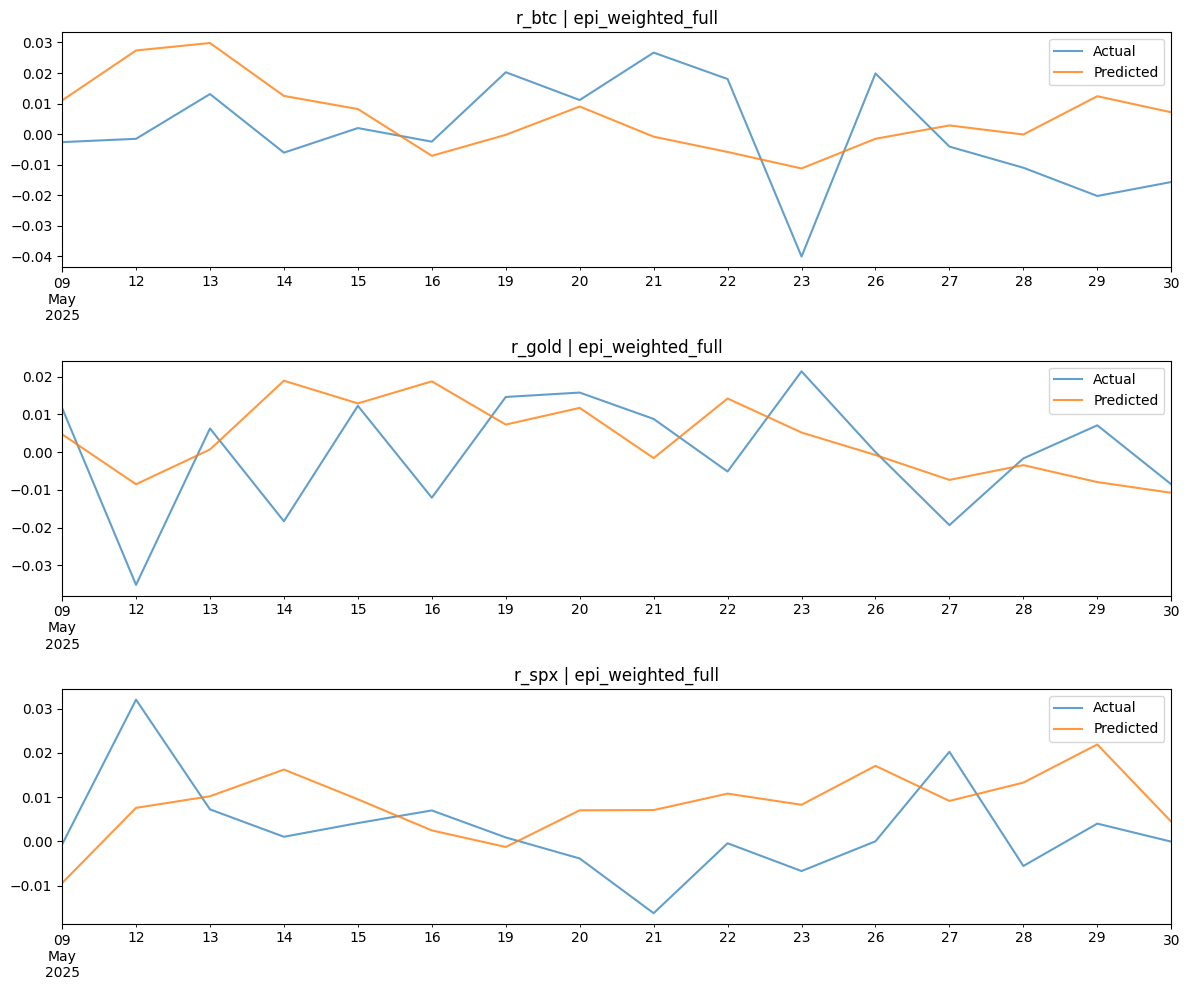

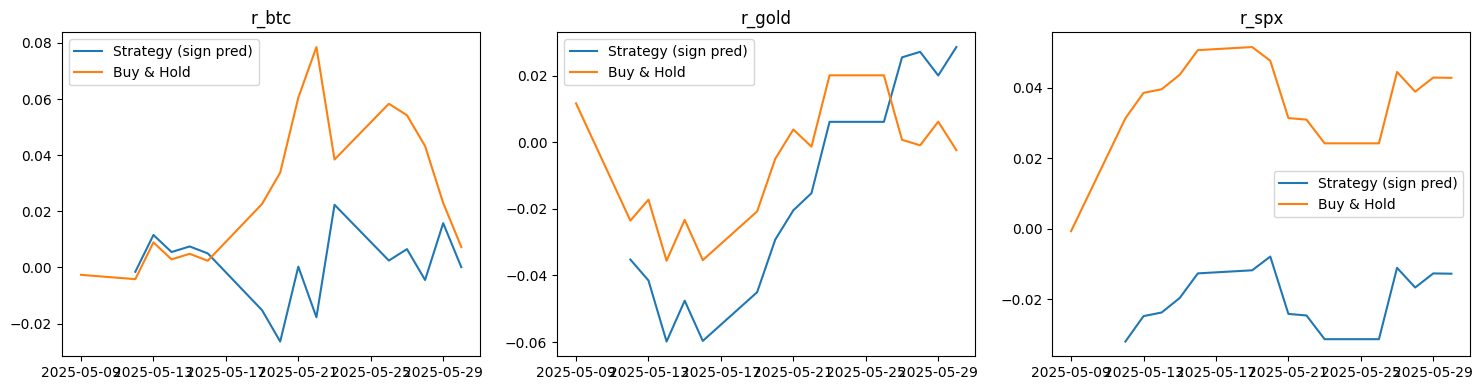

In [16]:

if not comparison_df.empty:
    best_model_type = comparison_df.groupby("Model")["RMSE"].mean().idxmin()
    print(f"Using best average RMSE model type: {best_model_type}")
else:
    best_model_type = "baseline"
    print("No successful runs; using baseline placeholder.")

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for idx, asset in enumerate(assets):
    res = results.get(best_model_type, {}).get(asset)
    if not res or "error" in res:
        axes[idx].set_title(f"{asset}: no predictions")
        continue
    ax = axes[idx]
    res["actuals"].plot(ax=ax, label="Actual", alpha=0.7)
    res["predictions"].plot(ax=ax, label="Predicted", alpha=0.8)
    ax.set_title(f"{asset} | {best_model_type}")
    ax.legend()
plt.tight_layout()
plt.show()

# Cumulative returns using one-step-ahead sign of predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, asset in enumerate(assets):
    res = results.get(best_model_type, {}).get(asset)
    if not res or "error" in res:
        axes[idx].set_title(f"{asset}: no returns plot")
        continue
    actuals = res["actuals"]
    preds = res["predictions"]
    strategy = (np.sign(preds.shift(1)) * actuals).cumsum()
    buy_hold = actuals.cumsum()
    axes[idx].plot(strategy, label="Strategy (sign pred)")
    axes[idx].plot(buy_hold, label="Buy & Hold")
    axes[idx].set_title(asset)
    axes[idx].legend()
plt.tight_layout()
plt.show()


## 8. Notes / next steps
- MLX runs best on Apple Silicon with recent Python builds; if `batch_first` is unsupported, the fallback in `LSTMRegressor` handles the axis swap.
- Increase `seq_len`, `hidden_size`, and `epochs` for richer dynamics (data volume is small, so watch for overfitting).
- You can extend `model_types` to mirror every XGBoost spec or simplify to the one that works best in this window.